1.  Explain the differences between AI, ML, Deep Learning (DL), and Data
Science (DS).

* Artificial Intelligence (AI):

* AI = Computer behaves like a human.

* AI is the big umbrella.

* Goal: Make machines think, learn, and make decisions like humans.

* Examples: Siri / Alexa, Self-driving cars

* Machine Learning (ML):

* ML = Teach the computer using data instead of rules.

* ML is a subset of AI.

* In ML, the computer learns patterns from data. No manual programming of rules data teaches the model.

* Examples: Predict house price, Spam mail detection

* Deep Learning (DL):

* DL = Machine Learning using neural networks (brain-like structure).

* DL is a subset of ML.

* Works very well for complex data: Images, Videos

* Data Science (DS):

* DS = Working with data to extract insights + make decisions.

* DS is a broader field (not just AI/ML).

* It involves: Data cleaning, Data analysis, Data visualization, Statistics

* Sometimes ML to build predictive models

* Examples: Sales forecasting, Customer analytics, Business dashboards, Data-driven decisions.

2. What are the types of machine learning? Describe each with one
real-world example.

* Supervised Learning : The machine learns the relationship and predicts outputs for new data.

* Used for: Prediction, Classification

* Real-world example: Spam Email Detection

* Input: Email content

* Output: Spam or Not Spam (label) The model learns from many labeled emails and detects spam automatically.

* Unsupervised Learning : The model finds patterns, groups, or structure on its own.

* Used for: Clustering, Finding hidden patterns

* Real-world example: Customer Segmentation (Amazon/Flipkart)

* Data: Purchase behavior, browsing habits

* No label (The model groups customers into similar segments (budget buyers, loyal customers, etc.))

* Semi-Supervised Learning : You give the model a small amount of labeled data and a large amount of unlabeled data.

* Used for: When labeling data is expensive, Improving accuracy with limited labels

* Real-world example: Google Photos — Face Grouping

* Only a few photos are labeled with names.

* The model uses many unlabeled images to group and learn faces accurately.

* Reinforcement Learning (RL) : A machine learns by trial and error.

* Used for: Decision-making, Games

* Real-world example: Self-Driving Cars

* The car learns Reward: safe driving, staying in lane

* Penalty: harsh braking, collisions

* Over time, it improves driving decisions.

3.  Define overfitting, underfitting, and the bias-variance tradeoff in machine
learning.

* Overfitting : A model learns too much, including the noise in the training data. It performs very well on training data but poorly on new, unseen data.

* Model memorizes instead of learning.

*Real-world example: A student memorizes exact answers from the textbook - scores well in practice tests - fails in the final exam with new questions.

* Underfitting : A model is too simple and fails to learn important patterns in data. It performs poorly on both training and test data.

* Real-world example: A student studies only the basics - cannot answer even practice questions - gets low marks everywhere.

4.  What are outliers in a dataset, and list three common techniques for
handling them.

* Outliers are data points that are significantly different from the rest of the dataset. They are either too high or too low compared to normal values.

* Example: In a class of students aged 18–22, if one entry shows age 70, it is an outlier.

* Common Techniques : Removing Outliers, Capping (Winsorization), Transformation Methods.

5. Explain the process of handling missing values and mention one
imputation technique for numerical and one for categorical data.

* Process of Handling Missing Values : Handling missing values is an important step in data cleaning.

* Identify Missing Values, Analyze the Reason for Missingness, Choose a Handling Method, Apply the Imputation Technique, Validate the Result.


In [1]:
# Write a Python program that: Creates a synthetic imbalanced dataset with make_classification() from sklearn.datasets. Prints the class distribution.
# answer
from sklearn.datasets import make_classification
from collections import Counter

# Create an imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=3,
    n_redundant=1,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],  # 90% of class 0, 10% of class 1
    random_state=42
)

# Print class distribution
class_distribution = Counter(y)
print("Class Distribution:", class_distribution)

Class Distribution: Counter({np.int64(0): 892, np.int64(1): 108})


In [2]:
# Implement one-hot encoding using pandas for the following list of colors: ['Red', 'Green', 'Blue', 'Green', 'Red']. Print the resulting dataframe.
# answer
import pandas as pd

colors = ['Red', 'Green', 'Blue', 'Green', 'Red']
df = pd.DataFrame({'Color': colors})

one_hot = pd.get_dummies(df, columns=['Color'])
print(one_hot)


   Color_Blue  Color_Green  Color_Red
0       False        False       True
1       False         True      False
2        True        False      False
3       False         True      False
4       False        False       True


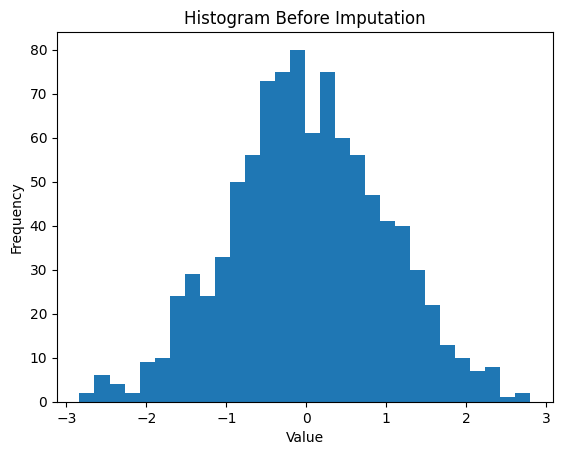

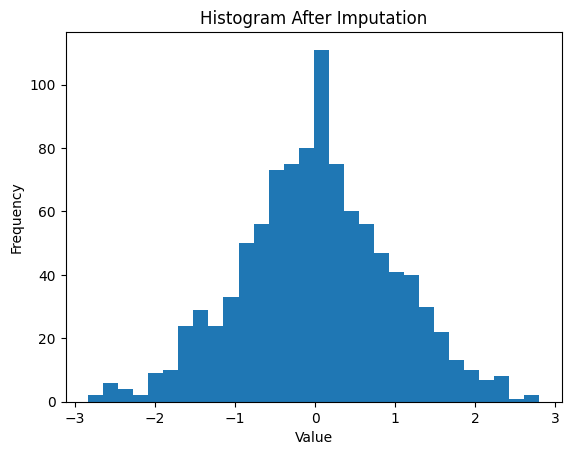

In [3]:
# Write a Python script to: Generate 1000 samples from a normal distribution. Introduce 50 random missing values. Fill missing values with the column mean. Plot a histogram before and after imputation.
# answer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Generate 1000 samples from a normal distribution
data = np.random.normal(loc=0, scale=1, size=1000)

# Step 2: Introduce 50 random missing values
data_with_nan = data.copy()
nan_indices = np.random.choice(1000, 50, replace=False)
data_with_nan[nan_indices] = np.nan

# Save original data before imputation
original_data = data_with_nan.copy()

# Step 3: Fill missing values with the column mean
mean_value = np.nanmean(data_with_nan)
data_filled = np.where(np.isnan(data_with_nan), mean_value, data_with_nan)

# Step 4: Plot histograms before and after imputation
plt.hist(original_data[~np.isnan(original_data)], bins=30)
plt.title("Histogram Before Imputation")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.hist(data_filled, bins=30)
plt.title("Histogram After Imputation")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [4]:
# Implement Min-Max scaling on the following list of numbers [2, 5, 10, 15, 20] using sklearn.preprocessing.MinMaxScaler. Print the scaled array.
# answer
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Original data
data = np.array([[2], [5], [10], [15], [20]])

# Create scaler
scaler = MinMaxScaler()

# Fit and transform
scaled_data = scaler.fit_transform(data)

print("Original Data:\n", data.flatten())
print("Scaled Data:\n", scaled_data.flatten())


Original Data:
 [ 2  5 10 15 20]
Scaled Data:
 [0.         0.16666667 0.44444444 0.72222222 1.        ]


In [6]:
# You are working as a data scientist for a retail company. You receive a customer transaction dataset that contains: Missing ages, Outliers in transaction amount, A highly imbalanced target (fraud vs. non-fraud), Categorical variables like payment method.
# answer
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import RandomOverSampler

# -------------------------
# 1. Create a small sample dataset
# -------------------------
df = pd.DataFrame({
    'Age': [25, np.nan, 40, 35, np.nan, 30],
    'Amount': [200, 5000, 250, 300, 100000, 280],   # 100000 is an outlier
    'Payment_Method': ['Card', 'UPI', 'Cash', 'Card', 'UPI', 'Cash'],
    'Fraud': [0, 0, 0, 0, 1, 0]  # imbalanced target
})

print("Original Dataset:\n", df, "\n")

# -------------------------
# 2. Fill missing Age with mean
# -------------------------
df['Age'] = df['Age'].fillna(df['Age'].mean())

# -------------------------
# 3. Remove outliers using IQR
# -------------------------
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]

print("After Removing Outliers:\n", df, "\n")

# -------------------------
# 4. One-Hot encode categorical Payment Method
# -------------------------
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['Payment_Method']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Payment_Method']))

df = pd.concat([df.drop('Payment_Method', axis=1), encoded_df], axis=1)

print("After Encoding Categorical Variable:\n", df, "\n")

# -------------------------
# 5. Handle Imbalanced Target using Oversampling
# -------------------------
ros = RandomOverSampler()
X_resampled, y_resampled = ros.fit_resample(df.drop('Fraud', axis=1), df['Fraud'])

final_df = pd.concat([X_resampled, y_resampled], axis=1)

print("After Handling Imbalanced Data:\n", final_df)


Original Dataset:
     Age  Amount Payment_Method  Fraud
0  25.0     200           Card      0
1   NaN    5000            UPI      0
2  40.0     250           Cash      0
3  35.0     300           Card      0
4   NaN  100000            UPI      1
5  30.0     280           Cash      0 

After Removing Outliers:
     Age  Amount Payment_Method  Fraud
0  25.0     200           Card      0
1  32.5    5000            UPI      0
2  40.0     250           Cash      0
3  35.0     300           Card      0
5  30.0     280           Cash      0 

After Encoding Categorical Variable:
     Age  Amount  Fraud  Payment_Method_Card  Payment_Method_Cash  \
0  25.0   200.0    0.0                  1.0                  0.0   
1  32.5  5000.0    0.0                  0.0                  0.0   
2  40.0   250.0    0.0                  0.0                  1.0   
3  35.0   300.0    0.0                  1.0                  0.0   
5  30.0   280.0    0.0                  NaN                  NaN   
4   NaN    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:399: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y contains NaN.